In [ ]:
import os
os.chdir("./../..")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import matplotlib
from pathlib import Path

# Loading dataset

New raw alarms source collected differently from `alarms-merged.csv`: three separate feeds by granularity instead of one flat file.

In [3]:
raw_path = Path("data/alarms/0_2_alarms_source_raw")

region = pd.read_csv(raw_path / "alarms-region-lvl.csv", sep=";")
districts = pd.read_csv(raw_path / "alarms-districts-lvl.csv", sep=";")
kyiv = pd.read_csv(raw_path / "alarms-kyiv-lvl.csv", sep=";")

region["source"] = "region"
districts["source"] = "districts"
kyiv["source"] = "kyiv"

alarms_raw = pd.concat([region, districts, kyiv], ignore_index=True)
alarms_raw.head()

,id,region_id,region_title,region_city,all_region,start,end,source
0,52432,12,Львівська область,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,region
1,53292,23,Чернігівська область,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,region
2,52080,3,Вінницька область,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,region
3,52857,19,Харківська область,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47,region
4,52700,18,Тернопільська область,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19,region


In [4]:
alarms_raw.groupby("source").size().rename("rows")

source
districts    44738
kyiv          2073
region       64006
Name: rows, dtype: int64

- `region-lvl` covers oblast-wide alerts (`all_region=1`), `districts-lvl` covers raion-level alerts, and `kyiv-lvl` covers only the city of Kyiv — three separate feeds, not duplicates of the same events.

# Data Preparation

In [5]:
alarms_raw["start"] = pd.to_datetime(alarms_raw["start"])
alarms_raw["end"] = pd.to_datetime(alarms_raw["end"])
alarms_raw["duration_min"] = (alarms_raw["end"] - alarms_raw["start"]).dt.total_seconds() / 60

alarms_raw["start_hour"] = alarms_raw["start"].dt.hour
alarms_raw["day_of_week"] = alarms_raw["start"].dt.day_name().str.lower()
alarms_raw["date"] = alarms_raw["start"].dt.date
alarms_raw["month"] = alarms_raw["start"].dt.to_period("M").astype(str)

alarms_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 110817 entries, 0 to 110816
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            110817 non-null  int64         
 1   region_id     110817 non-null  int64         
 2   region_title  110817 non-null  str           
 3   region_city   110817 non-null  str           
 4   all_region    110817 non-null  int64         
 5   start         110817 non-null  datetime64[us]
 6   end           110817 non-null  datetime64[us]
 7   source        110817 non-null  str           
 8   duration_min  110817 non-null  float64       
 9   start_hour    110817 non-null  int32         
 10  day_of_week   110817 non-null  str           
 11  date          110817 non-null  object        
 12  month         110817 non-null  str           
dtypes: datetime64[us](2), float64(1), int32(1), int64(3), object(1), str(5)
memory usage: 19.4+ MB


In [6]:
alarms_raw.isna().sum()

id              0
region_id       0
region_title    0
region_city     0
all_region      0
start           0
end             0
source          0
duration_min    0
start_hour      0
day_of_week     0
date            0
month           0
dtype: int64

- no missing values in any column across all three sources.

In [7]:
print("duplicate ids within each source:")
print(alarms_raw.groupby("source")["id"].apply(lambda s: s.duplicated().sum()))

ids_by_source = {name: set(df["id"]) for name, df in alarms_raw.groupby("source")}
print("\nid overlap across sources:")
print("region & districts:", len(ids_by_source["region"] & ids_by_source["districts"]))
print("region & kyiv:", len(ids_by_source["region"] & ids_by_source["kyiv"]))
print("districts & kyiv:", len(ids_by_source["districts"] & ids_by_source["kyiv"]))

duplicate ids within each source:
source
districts    0
kyiv         0
region       0
Name: id, dtype: int64

id overlap across sources:
region & districts: 0
region & kyiv: 0
districts & kyiv: 0


- no duplicate `id`s within any source, and zero `id` overlap across sources — these are complementary feeds sharing one global id sequence, not the same alerts recorded three times.

## Cleaning anomalies

In [8]:
# before_counts = alarms_raw.groupby("source").size()

# alarms = alarms_raw[(alarms_raw["duration_min"] > 0) & (alarms_raw["duration_min"] <= 1440)].copy()

# after_counts = alarms.groupby("source").size()
# (before_counts - after_counts).rename("rows_dropped")

alarms = alarms_raw.copy()

- dropped rows with non-positive duration or lasting more than 24 hours, same rule as `eda_alarms.ipynb`.
- `districts-lvl` lost the most rows (223) — mostly alerts lasting over a day, likely raion alerts held open by a still-active, broader oblast-level threat.
- `region-lvl` lost 12 rows, `kyiv-lvl` lost none.

# EDA

## Collection method transition: region-lvl vs districts-lvl over time

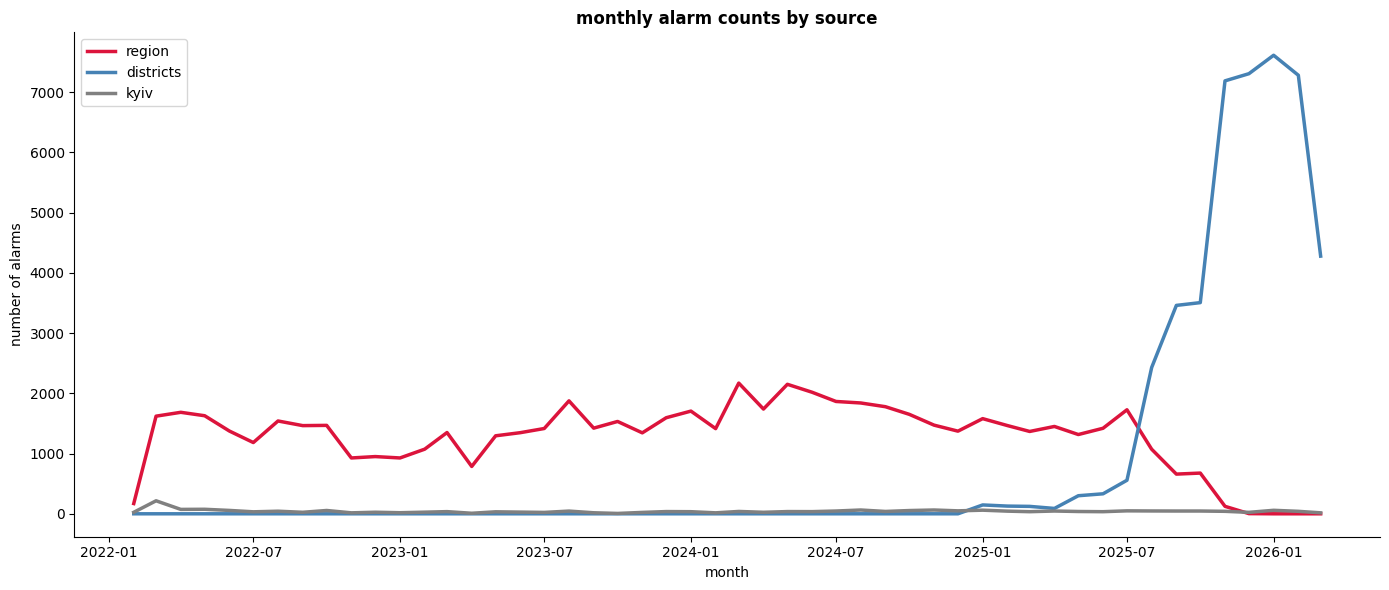

In [9]:
monthly = alarms.groupby(["month", "source"]).size().unstack(fill_value=0)
monthly.index = pd.PeriodIndex(monthly.index, freq="M").to_timestamp()
monthly = monthly.sort_index()

plt.figure(figsize=(14, 6))
for source, color in zip(["region", "districts", "kyiv"], ["crimson", "steelblue", "grey"]):
    plt.plot(monthly.index, monthly[source], linewidth=2.5, label=source, color=color)

plt.title("monthly alarm counts by source", fontweight="bold")
plt.xlabel("month")
plt.ylabel("number of alarms")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

- `region-lvl` reporting tapers off through 2025 (from roughly 1,650/month in late 2024 to just 3 in December 2025) at almost exactly the moment `districts-lvl` ramps up from January 2025 onward.
- this is the "different collection method": the source switched from oblast-level to raion-level granularity partway through 2025, while `kyiv-lvl` was tracked separately and continuously throughout.
- any future merge needs to treat `region-lvl` and `districts-lvl` as sequential regimes, not two granularities of the same period.

## Top 15 regions by alarm count (region-lvl)

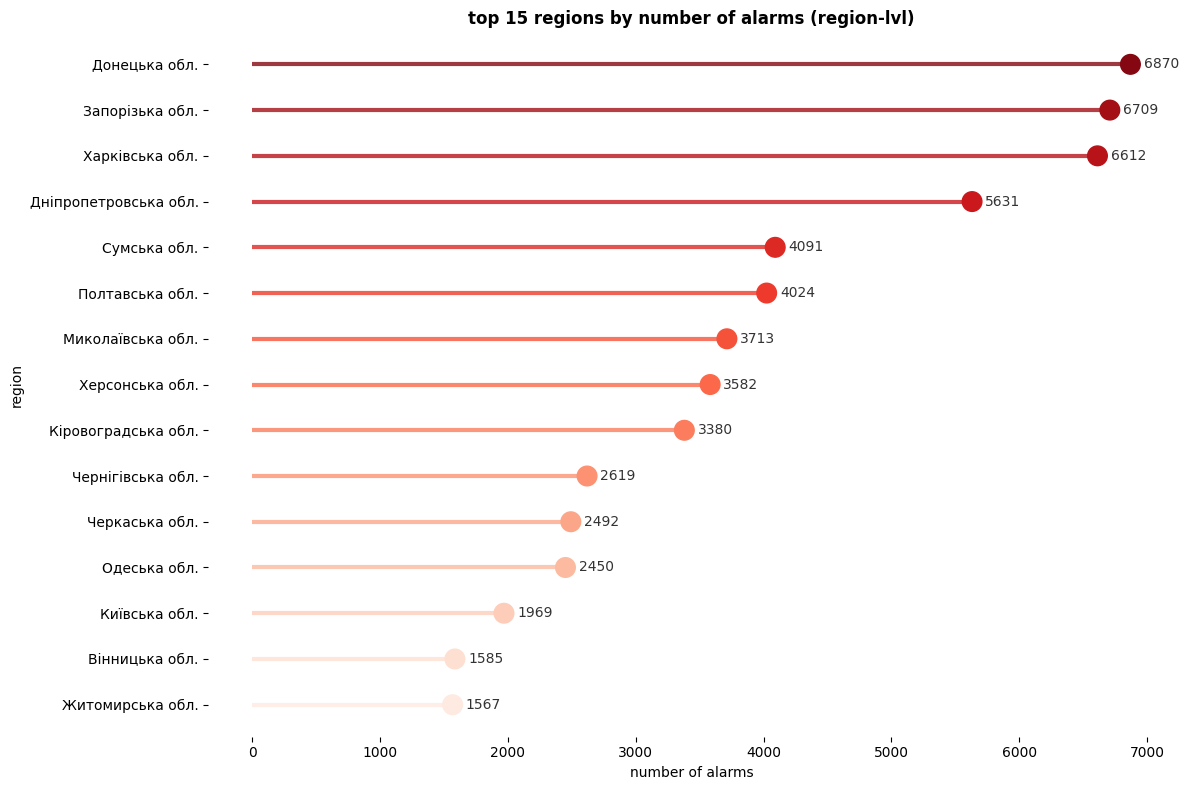

In [10]:
plt.figure(figsize=(12, 8))
alarms_by_region = alarms[alarms["source"] == "region"]["region_city"].value_counts().head(15)
alarms_by_region = alarms_by_region.sort_values(ascending=True)

colors = sns.color_palette("Reds", len(alarms_by_region))

plt.hlines(y=alarms_by_region.index, xmin=0, xmax=alarms_by_region.values, color=colors, linewidth=3, alpha=0.8)
plt.scatter(alarms_by_region.values, alarms_by_region.index, color=colors, s=200, alpha=1, zorder=3)

for i, (value, name) in enumerate(zip(alarms_by_region.values, alarms_by_region.index)):
    plt.text(value + (max(alarms_by_region.values) * 0.015), i, f"{value}", va="center", color="#333333")

plt.title("top 15 regions by number of alarms (region-lvl)", fontweight="bold")
plt.xlabel("number of alarms")
plt.ylabel("region")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

- consistent with `eda_alarms.ipynb`: eastern and southern oblasts dominate the region-level counts.

## Top 20 districts by alarm count (districts-lvl)

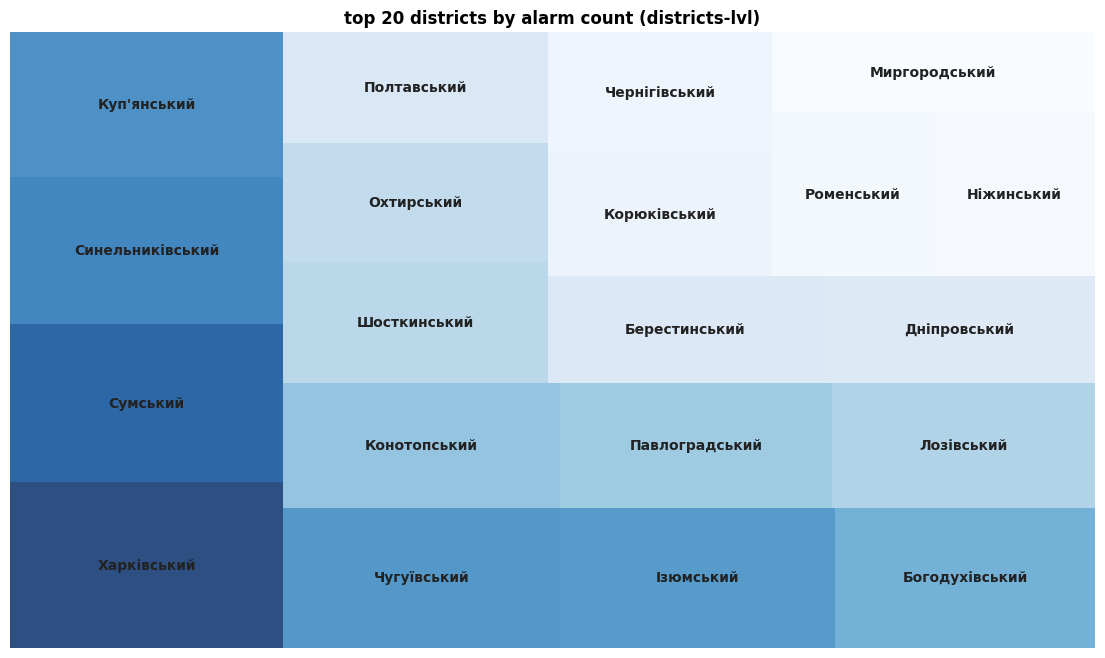

In [11]:
plt.figure(figsize=(14, 8))
district_counts = alarms[alarms["source"] == "districts"]["region_city"].value_counts().head(20)

cmap = matplotlib.colormaps["Blues"]
mini, maxi = district_counts.min(), district_counts.max()
norm = matplotlib.colors.Normalize(vmin=mini, vmax=maxi)
colors = [cmap(norm(value)) for value in district_counts.values]

squarify.plot(
    sizes=district_counts.values,
    label=district_counts.index,
    color=colors,
    alpha=0.85,
    text_kwargs={"fontsize": 10, "weight": "bold", "color": "#222222"},
)

plt.title("top 20 districts by alarm count (districts-lvl)", fontweight="bold")
plt.axis("off")
plt.show()

- top districts are raions in Kharkiv, Sumy, Chernihiv, Dnipropetrovsk and Poltava oblasts — all along or near the front line / border with Russia (e.g. Kharkivskyi, Sumskyi, Synelnykivskyi, Kupianskyi, Chuhuivskyi, Iziumskyi).
- `districts-lvl` gives visibility inside an oblast that `region-lvl` completely lacks — useful signal once merged into the main pipeline.

## Kyiv alerts over time

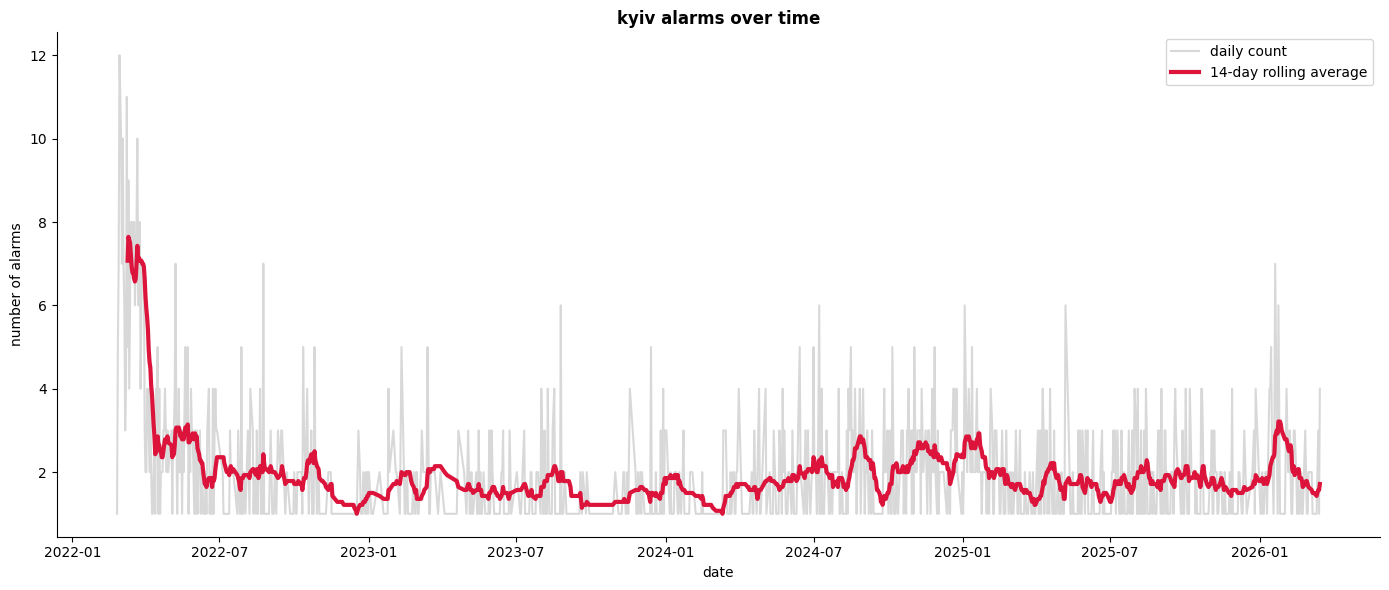

In [12]:
kyiv_daily = alarms[alarms["source"] == "kyiv"].groupby("date").size().reset_index(name="alarm_count")
kyiv_daily["date"] = pd.to_datetime(kyiv_daily["date"])
kyiv_daily = kyiv_daily.sort_values("date")
kyiv_daily["rolling_avg"] = kyiv_daily["alarm_count"].rolling(window=14).mean()

plt.figure(figsize=(14, 6))
plt.plot(kyiv_daily["date"], kyiv_daily["alarm_count"], color="grey", alpha=0.3, label="daily count")
plt.plot(kyiv_daily["date"], kyiv_daily["rolling_avg"], color="crimson", linewidth=3, label="14-day rolling average")

plt.title("kyiv alarms over time", fontweight="bold")
plt.xlabel("date")
plt.ylabel("number of alarms")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

- kyiv averages ~2 alerts/day (max 12, on 2022-02-28) with the highest daily counts concentrated in the first weeks of the full-scale invasion; the 14-day rolling average captures the long-run intensity well.

## Alarm duration distribution by source

C:\Users\Георгій\AppData\Local\Temp\ipykernel_25316\999130571.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


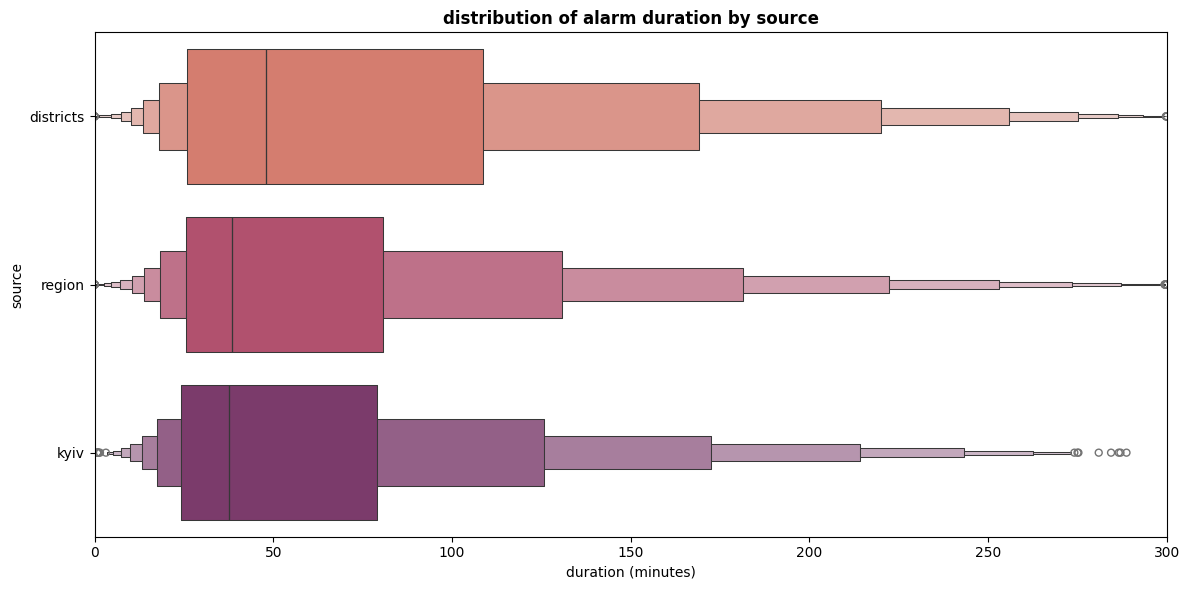

In [13]:
plt.figure(figsize=(12, 6))

order = alarms.groupby("source")["duration_min"].median().sort_values(ascending=False).index

sns.boxenplot(
    data=alarms[alarms["duration_min"] <= 300],
    x="duration_min",
    y="source",
    order=order,
    palette="flare",
)

plt.title("distribution of alarm duration by source", fontweight="bold")
plt.xlabel("duration (minutes)")
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

- `districts-lvl` alerts run noticeably longer than `region-lvl` (median ~60 min vs ~40 min) — raion alerts likely stay open while a broader, slower-moving threat lingers over the wider oblast.
- `kyiv-lvl` durations sit close to `region-lvl` (median ~39 min).

## Heatmap: alarm concentration by hour and day of week

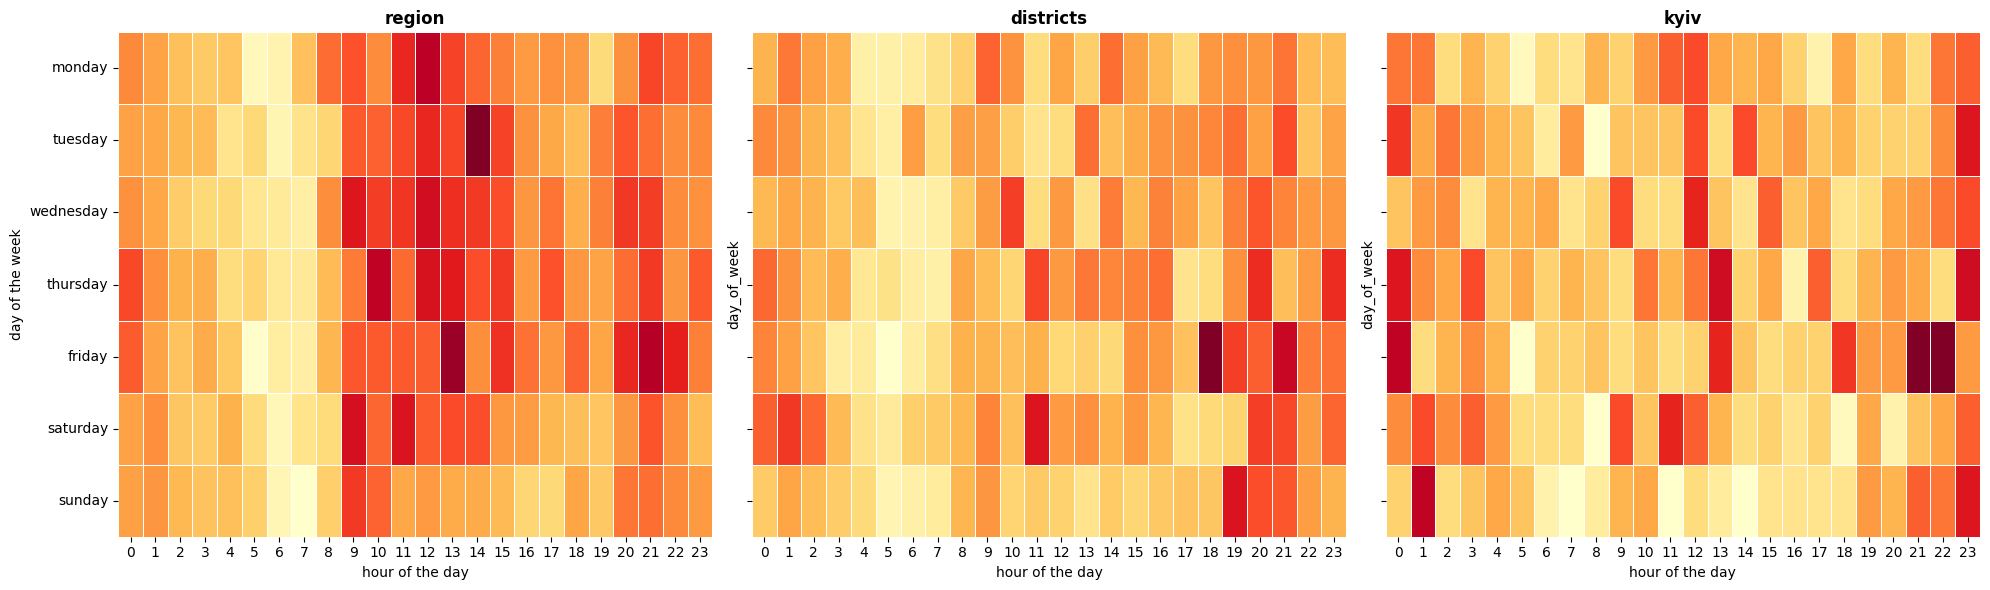

In [14]:
days_order = ["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, source in zip(axes, ["region", "districts", "kyiv"]):
    pivot = alarms[alarms["source"] == source].pivot_table(
        index="day_of_week", columns="start_hour", aggfunc="size", fill_value=0
    )
    pivot = pivot.reindex(days_order)
    sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(source, fontweight="bold")
    ax.set_xlabel("hour of the day")

axes[0].set_ylabel("day of the week")
plt.tight_layout()
plt.show()

- all three sources peak during daytime and late evening hours, mirroring the pattern already seen in `eda_alarms.ipynb` — the collection-method change did not change *when* alerts happen, only how they're recorded.

# Conclusions

- three complementary raw feeds, not duplicates: zero overlapping `id`s across sources, no nulls, no in-file duplicate ids.
- the headline finding is a **collection-method transition**, not new information at the same granularity: `region-lvl` reporting fades out through 2025 as `districts-lvl` ramps up from January 2025, with `kyiv-lvl` running continuously throughout as its own feed.
- cleaned out 12 `region-lvl`, 223 `districts-lvl`, and 0 `kyiv-lvl` rows with non-positive or >24h durations, using the same rule as `alarms-merged.csv`.
- `districts-lvl` alerts run longer than `region-lvl` ones (median ~60 min vs ~40 min) and surface raion-level detail — mostly frontline districts in Kharkiv, Sumy, Chernihiv, Dnipropetrovsk and Poltava oblasts — that `region-lvl` cannot show.
- time-of-day/day-of-week concentration is consistent across all three sources, so the pipeline's existing time-based features should transfer.
- any merge with `alarms-merged.csv` needs to account for the region→district regime change rather than treating the two as interchangeable granularities of the same period.